## Data from World Happiness Report

The World Happiness Report is an annual publication of the United Nations Sustainable Development Solutions Network. It contains articles, and rankings of national happiness based on respondent ratings of their own lives, which the report also correlates with various life factors.

In this notebook we will explore the happiness of different countries and the features associated.
The datasets that we will use are available in *Data*: **happiness2020.pkl** and **countries_info.csv**.

Although the features are self-explanatory, here a summary: 

**happiness2020.pkl**
* country: *Name of the country*
* happiness_score: *Happiness score*
* social_support: *Social support (mitigation the effects of inequality)*
* healthy_life_expectancy: *Healthy Life Expectancy*
* freedom_of_choices: *Freedom to make life choices*
* generosity: *Generosity (charity, volunteers)*
* perception_of_corruption: *Corruption Perception*
* world_region: *Area of the world of the country*

**countries_info.csv**
* country_name: *Name of the country*
* area: *Area in sq mi*
* population: *Number of people*
* literacy: *Literacy percentage*

In [1]:
!head Data/countries_info.csv

country_name,area,population,literacy
afghanistan,647500,31056997,"36,0"
albania,28748,3581655,"86,5"
algeria,2381740,32930091,"70,0"
argentina,2766890,39921833,"97,1"
armenia,29800,2976372,"98,6"
australia,7686850,20264082,"100,0"
austria,83870,8192880,"98,0"
azerbaijan,86600,7961619,"97,0"
bahrain,665,698585,"89,1"


In [65]:
import pandas as pd
%matplotlib inline

DATA_FOLDER = 'Data/'

HAPPINESS_DATASET = DATA_FOLDER+"happiness2020.csv"
COUNTRIES_DATASET = DATA_FOLDER+"countries_info.csv"

## Task 1: Load the data

Load the 2 datasets in Pandas dataframes (called *happiness* and *countries*), and show the first rows.


**Hint**: Use the correct reader and verify the data has the expected format.

In [66]:
# Write your code here
happiness = pd.read_csv(HAPPINESS_DATASET)
countries = pd.read_csv(COUNTRIES_DATASET)

In [67]:
print(happiness.shape)
print(countries.shape)

(135, 8)
(135, 4)


In [68]:
happiness.dropna(subset='country', inplace=True)
countries.dropna(subset='country_name', inplace=True)

In [69]:
print(happiness.shape)
print(countries.shape)

(135, 8)
(135, 4)


In [70]:
happiness.head()

,country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region
0,Afghanistan,2.5669,0.470367,52.590000,0.396573,-0.096429,0.933687,South Asia
1,Albania,4.8827,0.671070,68.708138,0.781994,-0.042309,0.896304,Central and Eastern Europe
2,Algeria,5.0051,0.803385,65.905174,0.466611,-0.121105,0.735485,Middle East and North Africa
3,Argentina,5.9747,0.900568,68.803802,0.831132,-0.194914,0.842010,Latin America and Caribbean
4,Armenia,4.6768,0.757479,66.750656,0.712018,-0.138780,0.773545,Commonwealth of Independent States


In [71]:
countries.dtypes

country_name      str
area            int64
population      int64
literacy          str
dtype: object

In [72]:
countries['country_name'] = countries['country_name'].str.capitalize()
countries['literacy'] = countries['literacy'].str.replace(',', '.').astype('float64') / 100
countries.head()


,country_name,area,population,literacy
0,Afghanistan,647500,31056997,0.360
1,Albania,28748,3581655,0.865
2,Algeria,2381740,32930091,0.700
3,Argentina,2766890,39921833,0.971
4,Armenia,29800,2976372,0.986


## Task 2: Let's merge the data

Create a dataframe called *country_features* by merging *happiness* and *countries*. A row of this dataframe must describe all the features that we have about a country.

**Hint**: Verify that all the rows are in the final dataframe.

In [73]:
# Write your code here
country_features = pd.merge(countries, happiness, how='outer', left_on='country_name', right_on='country')

In [74]:
print(country_features.shape)
country_features.head()

(148, 12)


,country_name,area,population,literacy,country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region
0,Afghanistan,647500.0,31056997.0,0.360,Afghanistan,2.5669,0.470367,52.590000,0.396573,-0.096429,0.933687,South Asia
1,Albania,28748.0,3581655.0,0.865,Albania,4.8827,0.671070,68.708138,0.781994,-0.042309,0.896304,Central and Eastern Europe
2,Algeria,2381740.0,32930091.0,0.700,Algeria,5.0051,0.803385,65.905174,0.466611,-0.121105,0.735485,Middle East and North Africa
3,Argentina,2766890.0,39921833.0,0.971,Argentina,5.9747,0.900568,68.803802,0.831132,-0.194914,0.842010,Latin America and Caribbean
4,Armenia,29800.0,2976372.0,0.986,Armenia,4.6768,0.757479,66.750656,0.712018,-0.138780,0.773545,Commonwealth of Independent States


## Task 3: Where are people happier?

Print the top 10 countries based on their happiness score (higher is better).

In [75]:
# Write your code here
print(country_features.sort_values(ascending=False, by='happiness_score')['country'].head(10))

43         Finland
34         Denmark
125    Switzerland
55         Iceland
98          Norway
92     Netherlands
124         Sweden
93     New Zealand
6          Austria
77      Luxembourg
Name: country, dtype: str


We are interested to know in what world region people are happier. 

Create and print a dataframe with the (1) average happiness score and (2) the number of contries for each world region.
Sort the result to show the happiness ranking.

In [76]:
# Write your code here
countries_grouped = country_features[['country', 'world_region', 'happiness_score']].groupby('world_region')

countries_grouped_df = countries_grouped.agg(
    country_count=('country', 'count'),
    mean_happiness=('happiness_score', 'mean')
).reset_index()

# alternative way
countries_grouped_df = pd.DataFrame({
    'country_count': countries_grouped['country'].count(),
    'mean_happiness': countries_grouped['happiness_score'].mean(),
}).reset_index()

countries_grouped_df.sort_values(by='mean_happiness', ascending=False)

,world_region,country_count,mean_happiness
5,North America and ANZ,4,7.173525
9,Western Europe,20,6.967405
3,Latin America and Caribbean,20,5.971280
0,Central and Eastern Europe,14,5.891393
7,Southeast Asia,8,5.517788
2,East Asia,3,5.483633
1,Commonwealth of Independent States,12,5.358342
4,Middle East and North Africa,16,5.269306
8,Sub-Saharan Africa,32,4.393856
6,South Asia,6,4.355083


The first region has only a few countries! What are them and what is their score?

In [77]:
# Write your code here
north_america_countries = country_features[country_features['world_region'] == 'North America and ANZ']
north_america_countries[['country', 'happiness_score']]

,country,happiness_score
5,Australia,7.2228
22,Canada,7.2321
93,New Zealand,7.2996
137,United States,6.9396


## Task 4: How literate is the world?

Print the names of the countries with a level of literacy of 100%. 

For each country, print the name and the world region in the format: *{region name} - {country name} ({happiness score})*

In [80]:
# Write your code here
literate_countries = country_features[country_features['literacy'] >= 1]

for row in literate_countries.itertuples():
    print(f"{row.world_region} - {row.country} {row.happiness_score}")

North America and ANZ - Australia 7.222799778
Western Europe - Denmark 7.645599842
Western Europe - Finland 7.808700085
Western Europe - Luxembourg 7.237500191
Western Europe - Norway 7.487999916000001


What is the global average?

In [81]:
# Write your code here
country_features['literacy'].mean()

np.float64(0.8185112781954886)

Calculate the proportion of countries with a literacy level below 50%. Print the value in percentage, formatted with 2 decimals.

In [86]:
illiterate_countries = country_features[country_features['literacy'] < 0.5]

In [87]:
# Write your code here
total_country_count = len(country_features)
illiterate_country_count = len(illiterate_countries)

illiterate_countries_proportion = illiterate_country_count / total_country_count * 100
print(f"{illiterate_countries_proportion:.2f} %")

10.81 %


Print the raw number and the percentage of world population that is illiterate.

In [91]:
# Write your code here
world_population = country_features['population'].sum()
illiterate_population = illiterate_countries['population'].sum()

print(illiterate_population)
print(f"{illiterate_population / world_population * 100:.2f} %")

580572946.0
9.45 %


## Task 5: Population density

Add to the dataframe a new field called *population_density* computed by dividing *population* by *area*.

In [92]:
# Write your code here
country_features['population_density'] = country_features['population'] / country_features['area']
country_features.head()

,country_name,area,population,literacy,country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region,population_density
0,Afghanistan,647500.0,31056997.0,0.360,Afghanistan,2.5669,0.470367,52.590000,0.396573,-0.096429,0.933687,South Asia,47.964474
1,Albania,28748.0,3581655.0,0.865,Albania,4.8827,0.671070,68.708138,0.781994,-0.042309,0.896304,Central and Eastern Europe,124.587971
2,Algeria,2381740.0,32930091.0,0.700,Algeria,5.0051,0.803385,65.905174,0.466611,-0.121105,0.735485,Middle East and North Africa,13.826065
3,Argentina,2766890.0,39921833.0,0.971,Argentina,5.9747,0.900568,68.803802,0.831132,-0.194914,0.842010,Latin America and Caribbean,14.428413
4,Armenia,29800.0,2976372.0,0.986,Armenia,4.6768,0.757479,66.750656,0.712018,-0.138780,0.773545,Commonwealth of Independent States,99.878255


What is the happiness score of the 3 countries with the lowest population density?

In [94]:
# Write your code here
country_features.sort_values(by='population_density')[['country','happiness_score']].head(3)

,country,happiness_score
88,Mongolia,5.4562
5,Australia,7.2228
14,Botswana,3.4789


## Task 6: Healty and happy?

Plot in a scatter plot the happiness score (x) and healty life expectancy (y).

<Axes: xlabel='happiness_score', ylabel='healthy_life_expectancy'>

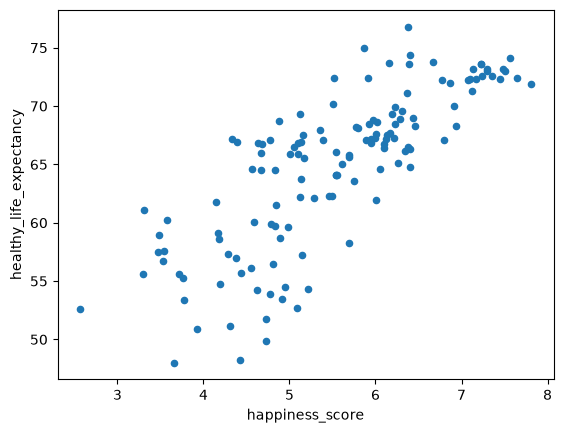

In [95]:
# Write your code here
country_features.plot.scatter(x='happiness_score', y='healthy_life_expectancy')

Feel free to continue the exploration of the dataset! We'll release the solutions next week.

----
Enjoy EPFL and be happy, next year Switzerland must be #1.